# 04 — Training the CNN on Google Colab (GPU)

Use this when you don't have a local GPU. The code and data live in a Google
Drive folder; Colab mounts it, runs your code, and writes the trained weights
back to Drive.

## Preliminary steps (do these once, before running)

1. In Google Drive create a folder **`qg_da`** in *My Drive* → path `MyDrive/qg_da/`.
2. Copy your **code** files into `MyDrive/qg_da/`:
   `QG_2D.py`, `EnKF.py`, `Experiment.py`, `visualization.py`, `ml_model.py`.
3. Create `MyDrive/qg_da/da_data/` and copy your **training data** there:
   `enkf_run_long.nc` and `obs_full.nc` (produced locally by notebooks 02–03).
   For large files, drag-and-drop them in the Drive **website**.
4. Open this notebook in Colab → **Runtime ▸ Change runtime type ▸ GPU**.
5. Run all cells top to bottom.

The setup cell below checks that every required file is present and lists any
that are missing.

## After training

* Weights are saved to **`MyDrive/qg_da/ml_weights/cnn.pt`** (the last cell also
  triggers a browser download).
* Copy `cnn.pt` into your **local** project's `ml_weights/` folder, then run
  `05_ml_testing.ipynb` locally (CPU is fine for inference).

In [1]:
# --- Colab setup: mount Drive, run code from MyDrive/qg_da, check files ---
import os, sys
PROJECT_DRIVE = "/content/drive/MyDrive/qg_da"

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(PROJECT_DRIVE, exist_ok=True)
os.chdir(PROJECT_DRIVE); sys.path.insert(0, PROJECT_DRIVE)
os.makedirs("da_data", exist_ok=True); os.makedirs("ml_weights", exist_ok=True)

need = ["QG_2D.py", "EnKF.py", "Experiment.py", "visualization.py", "ml_model.py",
        "da_data/enkf_run_long.nc", "da_data/obs_full.nc"]
missing = [f for f in need if not os.path.exists(f)]
if missing:
    print("MISSING from", PROJECT_DRIVE, "-> copy these in, then re-run:")
    for f in missing: print("   -", f)
else:
    print("all required files present in", PROJECT_DRIVE)

import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "NONE  (set Runtime > Change runtime type > GPU)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
all required files present in /content/drive/MyDrive/qg_da
GPU: NVIDIA A100-SXM4-40GB


In [2]:
import os, numpy as np, matplotlib.pyplot as plt, xarray as xr
%matplotlib inline
import torch, torch.nn as nn

from QG_2D import QG2D
from ml_model import PeriodicCNN, build_dataset, get_device

device = get_device()
os.makedirs("da_data", exist_ok=True); os.makedirs("ml_weights", exist_ok=True)

GPU available: NVIDIA A100-SXM4-40GB


## Load the dense-obs EnKF run (from notebook 03)

Needs `da_data/enkf_run_long.nc` (has `xf_mean`, `xa_mean`) and
`da_data/obs_full.nc`. If missing, a short run is generated so the notebook is
self-contained.

In [3]:
def _generate_small(nc=40, obs_every=24, dt=0.01, seed=42):
    from Experiment import Experiment, _save_run
    P=dict(N=64,beta=0.0,mu=0.1,nu=1e-3,p=2,A=4.0,k_f=4)
    m=QG2D(**P); qh=np.fft.fft2(m.random_ic(seed=seed,amp=2.0))
    for _ in range(int(40/dt)): qh=m.step(qh,dt)
    q0=np.real(np.fft.ifft2(qh)); clim=q0.std()
    d=m.random_ic(seed=7,amp=1.0); d*=0.05*clim/d.std(); win=nc*obs_every*dt
    control=m.run(q0,tf=win,dt=dt,spinup=0,store_every=obs_every,path="da_data/control.nc")
    truth=m.run(q0+d,tf=win,dt=dt,spinup=0,store_every=obs_every,path="da_data/truth.nc")
    sig=0.1*float(truth.q.std()); rng=np.random.default_rng(0); mask=np.ones((64,64),bool)
    _save_run(xr.Dataset({"obs":(("time","y","x"),truth.q.values+rng.normal(0,sig,truth.q.shape)),
                          "mask":(("y","x"),mask.astype("i1"))},
              coords={"time":truth.time,"y":truth.y,"x":truth.x},
              attrs={**P,"sigma_obs":sig,"dt_obs":obs_every*dt,"coverage":1.0}),"da_data/obs_full.nc")
    mp={k:truth.attrs[k] for k in ["N","L","beta","mu","nu","p","A","k_f"]}
    Experiment(mp,truth,QG2D.load("da_data/obs_full.nc"),
               dict(nens=20,dt=dt,gamma=1.05,loc=1.0,init_spread=0.1)
              ).assimilate(ncycles=nc,x0=control.q.isel(time=0).values,
                           save_path="da_data/enkf_run_long.nc",progress=False)

if not (os.path.exists("da_data/enkf_run_long.nc") and os.path.exists("da_data/obs_full.nc")):
    print("training data not found -> generating a short run (run 02/03 for the full dataset)...")
    _generate_small()

run = QG2D.load("da_data/enkf_run_long.nc")
obs = QG2D.load("da_data/obs_full.nc")
N = int(run.attrs["N"])
print("run cycles:", run.sizes["time"], "| grid:", N)

run cycles: 2401 | grid: 64


## Build the dataset and split train / validation

Samples are `([x_f, y - x_f], x_a)` per cycle, normalized by the vorticity std;
first 80% of time for training, last 20% for validation.

In [4]:
X, Y, sigma = build_dataset(run, obs)          # (T,2,N,N), (T,1,N,N)
T = len(X); ntr = int(0.8 * T)
Xtr, Ytr, Xva, Yva = X[:ntr], Y[:ntr], X[ntr:], Y[ntr:]
print(f"samples: {T} (train {len(Xtr)}, val {len(Xva)}) | sigma={sigma:.3f}")
to = lambda a: torch.tensor(a, device=device)
Xtr_t, Ytr_t, Xva_t, Yva_t = to(Xtr), to(Ytr), to(Xva), to(Yva)

samples: 2400 (train 1920, val 480) | sigma=3.261


## Train the CNN

epoch   0  train 5.5543e-05  val 6.5885e-06
epoch  10  train 3.2366e-06  val 2.3382e-06
epoch  20  train 3.0562e-06  val 2.1296e-06
epoch  30  train 2.9433e-06  val 1.9920e-06
epoch  40  train 2.7329e-06  val 1.8924e-06
epoch  50  train 2.6416e-06  val 1.8145e-06
epoch  59  train 2.5781e-06  val 2.3218e-06


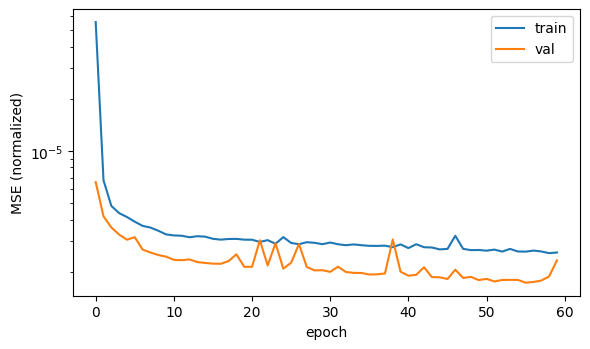

In [5]:
torch.manual_seed(0)
model = PeriodicCNN(in_ch=2, width=32, depth=4).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

EPOCHS, BATCH = 60, 16
n = len(Xtr_t); hist = {"train": [], "val": []}
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(n, device=device); tot = 0.0
    for i in range(0, n, BATCH):
        idx = perm[i:i+BATCH]; opt.zero_grad()
        loss = lossf(model(Xtr_t[idx]), Ytr_t[idx]); loss.backward(); opt.step()
        tot += loss.item() * len(idx)
    model.eval()
    with torch.no_grad(): vl = lossf(model(Xva_t), Yva_t).item()
    hist["train"].append(tot/n); hist["val"].append(vl)
    if ep % 10 == 0 or ep == EPOCHS-1:
        print(f"epoch {ep:3d}  train {hist['train'][-1]:.4e}  val {vl:.4e}")

plt.figure(figsize=(6,3.6))
plt.semilogy(hist["train"], label="train"); plt.semilogy(hist["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized)"); plt.legend(); plt.tight_layout(); plt.show()

## Save weights

In [6]:
ckpt = {"state_dict": model.state_dict(), "sigma": sigma,
        "arch": {"in_ch": 2, "width": 32, "depth": 4}}
torch.save(ckpt, "ml_weights/cnn.pt")
print("saved ml_weights/cnn.pt")

saved ml_weights/cnn.pt


## Check: does the CNN reproduce the EnKF analysis?

On the validation set, compare the CNN analysis to the true EnKF analysis and to
the forecast. A good emulator has analysis error well below the forecast error.

forecast   vs EnKF analysis RMSE : 0.0082
CNN output vs EnKF analysis RMSE : 0.0050


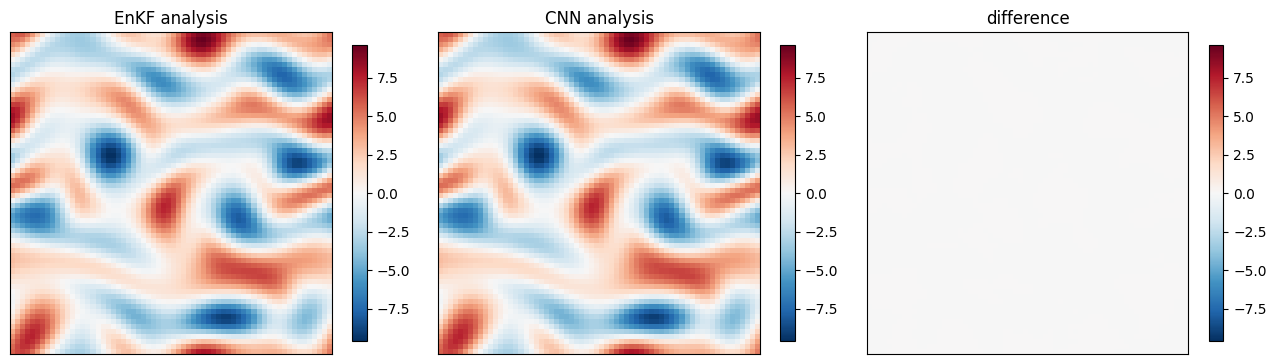

In [7]:
model.eval()
with torch.no_grad(): incr = model(Xva_t).cpu().numpy()[:, 0] * sigma   # predicted increment
xf_va = Xva[:, 0] * sigma
xa_va = xf_va + Yva[:, 0] * sigma      # true analysis (target is the increment)
pred  = xf_va + incr                  # predicted analysis = forecast + increment
rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))
print(f"forecast   vs EnKF analysis RMSE : {rmse(xf_va, xa_va):.4f}")
print(f"CNN output vs EnKF analysis RMSE : {rmse(pred,  xa_va):.4f}")

k = -1; v = np.abs(xa_va[k]).max()
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, f, t in zip(ax, [xa_va[k], pred[k], xa_va[k]-pred[k]],
                   ["EnKF analysis", "CNN analysis", "difference"]):
    im = a.imshow(f.T, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    a.set_title(t); a.set_xticks([]); a.set_yticks([]); fig.colorbar(im, ax=a, shrink=0.8)
fig.tight_layout(); plt.show()

## Download the trained weights

Saved on your Drive at `MyDrive/qg_da/ml_weights/cnn.pt`; this also downloads it
through the browser. Put it in your **local** `ml_weights/` folder for
`05_ml_testing.ipynb`.

In [8]:
from google.colab import files
files.download("ml_weights/cnn.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>